# UT4. Práctica 3: Filtros y Convoluciones
**Alumno/a:** Javier Peralta

En la sesión anterior trabajamos píxel a píxel. Hoy aprendemos el concepto más potente de la visión artificial: **La Vecindad**.
Vamos a construir "gafas matemáticas" (Kernels) para modificar cómo vemos la imagen.

### Objetivos:
1.  **La Matemática:** Calcular una convolución a mano.
2.  **Suavizado:** Eliminar ruido creando tus propios kernels (sin ayudas).
3.  **Bordes:** Traducir matrices matemáticas a NumPy.
4.  **Sharpen:** Enfocar una imagen desde cero.
5.  **Retos:** Filtros artísticos y algoritmos profesionales.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 6]

# --- HERRAMIENTA MATEMÁTICA (NO TOCAR) ---
# Como NumPy no tiene una función directa de convolución 2D para imágenes,
# hemos creado esta función optimizada para usar en la clase. 
# ¡Ejecuta esta celda para cargar la "máquina de convolución"!

def aplicar_convolucion(imagen, kernel):
    """
    Aplica una convolución a una imagen usando un kernel.
    Argumentos:
     - imagen: Matriz 2D de NumPy (Grises)
     - kernel: Matriz pequeña cuadrada (ej. 3x3 o 5x5)
    Devuelve:
     - Matriz con el filtro aplicado (tipo float)
    """
    # 1. Obtener dimensiones
    hi, wi = imagen.shape
    hk, wk = kernel.shape
    pad_y, pad_x = hk // 2, wk // 2
    
    # 2. Hacer Padding (Relleno de ceros alrededor para no perder bordes)
    img_pad = np.pad(imagen, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant')
    salida = np.zeros_like(imagen, dtype='float32')
    
    # 3. Aplicar la convolución (Optimizado vectorialmente)
    # En lugar de bucles lentos píxel a píxel, movemos la imagen completa
    for i in range(hk):
        for j in range(wk):
            # Desplazamos la imagen y multiplicamos por el valor del kernel
            val_kernel = kernel[i, j]
            # Recorte desplazado (Slicing)
            region = img_pad[i : i + hi, j : j + wi]
            salida += region * val_kernel
            
    return salida

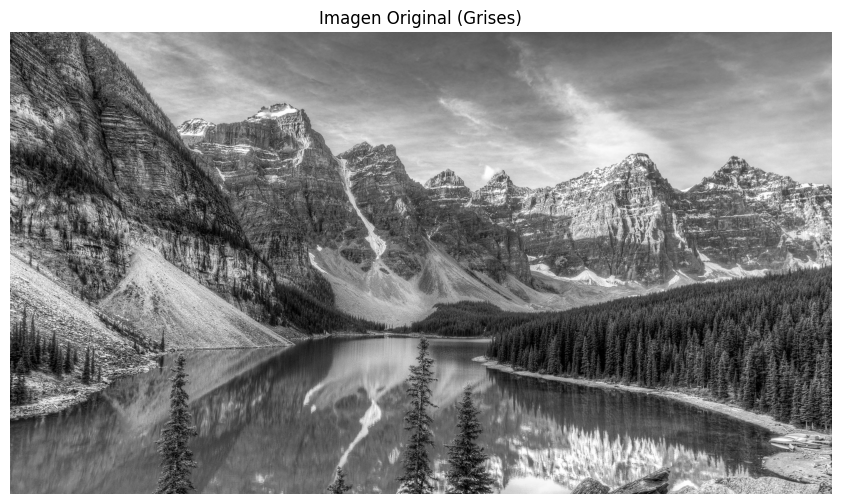

In [2]:
# CARGA DE IMAGEN
imagen = plt.imread('images/paisaje_2.jpg')


# PASAR A GRISES (Si es color)
if len(imagen.shape) == 3:
    # Fórmula: 0.299*R + 0.587*G + 0.114*B
    imagen_gris = (imagen[:,:,0]*0.299 + imagen[:,:,1]*0.587 + imagen[:,:,2]*0.114)
else:
    imagen_gris = imagen

# Normalizamos a float (0-255) por si acaso
imagen_gris = imagen_gris.astype('float32')

plt.imshow(imagen_gris, cmap='gray')
plt.title("Imagen Original (Grises)")
plt.axis('off')
plt.show()

---

## 1. La Matemática: "Soy una CPU humana"
Vamos a verificar que entendemos la **Convolución** calculando un píxel a mano.
Tenemos una matriz imagen ($5 \times 5$) y un **Kernel de Bordes Verticales** ($3 \times 3$).

$$ \text{Imagen} = \begin{bmatrix} 10 & 10 & 10 & 0 & 0 \\ 10 & 10 & 10 & 0 & 0 \\ 10 & 10 & \mathbf{10} & 0 & 0 \\ 10 & 10 & 10 & 0 & 0 \\ 10 & 10 & 10 & 0 & 0 \end{bmatrix} \quad \text{Kernel} = \begin{bmatrix} -1 & 0 & 1 \\ -1 & 0 & 1 \\ -1 & 0 & 1 \end{bmatrix} $$

**EJERCICIO MANUAL:**
Calcula el valor del **píxel central (2,2)** (el 10 en negrita) tras aplicar la convolución.
Recuerda: Superpón el centro del kernel sobre el 10, multiplica vecino con vecino y suma todo.

*Escribe aquí tu cálculo:* 
10 x -1 + 10 x 0 + 0 x 1 + 10 x -1 + 10 x 0 + 0 x 1 + 10 x -1 + 10 x 0 + 0 x 1 = -10 + 0 + 0 -10 + 0 + 0 -10 + 0 + 0 = -30

In [3]:
# COMPROBACIÓN CON CÓDIGO
input_mat = np.array([
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0]
], dtype='float32')

kernel_borde = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

# Usamos nuestra función mágica
salida = aplicar_convolucion(input_mat, kernel_borde)

print("Matriz Original:\n", input_mat)
print("\nResultado de la Convolución:\n", salida)
print("\nMira el centro de la matriz de resultado. ¿Coincide con tu cálculo?")

Matriz Original:
 [[10. 10. 10.  0.  0.]
 [10. 10. 10.  0.  0.]
 [10. 10. 10.  0.  0.]
 [10. 10. 10.  0.  0.]
 [10. 10. 10.  0.  0.]]

Resultado de la Convolución:
 [[ 20.   0. -20. -20.   0.]
 [ 30.   0. -30. -30.   0.]
 [ 30.   0. -30. -30.   0.]
 [ 30.   0. -30. -30.   0.]
 [ 20.   0. -20. -20.   0.]]

Mira el centro de la matriz de resultado. ¿Coincide con tu cálculo?


---

## 2. Filtros de Suavizado (Low Pass)
Vamos a limpiar el ruido. Para ello necesitas un **Kernel de Media** de $5 \times 5$.

**Tu Misión:**
1. Crea una matriz de $5 \times 5$ donde **todos los valores sean iguales**.
2. **IMPORTANTE:** Debes **normalizar** la matriz (dividir). Si la suma de todos los valores del kernel es mayor a 1, la imagen saldrá blanca (brillo excesivo). Si es 1, se mantiene el brillo original.
3. Aplica la convolución a `imagen_sucia` y guarda el resultado en `imagen_limpia`.

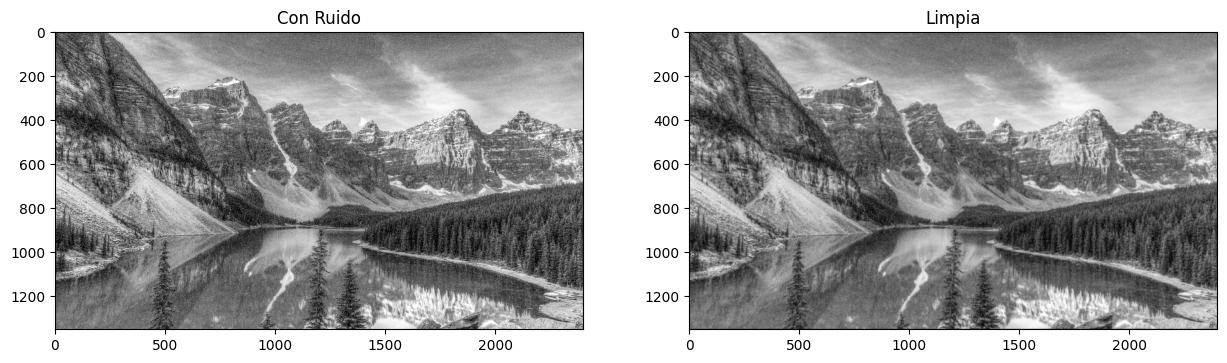

In [8]:
# PREPARACIÓN (No tocar): Generamos ruido en la imagen
ruido = np.random.randint(0, 2, size=imagen_gris.shape).astype('float32') * 255
mask_ruido = np.random.rand(*imagen_gris.shape) > 0.95
imagen_sucia = imagen_gris.copy()
imagen_sucia[mask_ruido] = 255

# --- TU CÓDIGO AQUÍ ---

# 1. Define tu kernel de media (5x5). 
# Piensa: ¿Qué operación matemática necesitas para hacer una media?
kernel_suave = np.ones((5, 5)) / 25

# 2. Aplica la convolución a 'imagen_sucia' y guárdalo en 'imagen_limpia'
imagen_limpia = aplicar_convolucion(imagen_sucia, kernel_suave)


# VISUALIZACIÓN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
ax1.imshow(imagen_sucia, cmap='gray'); ax1.set_title("Con Ruido")
# Si tu código falla, la siguiente línea dará error porque imagen_limpia no existe
if 'imagen_limpia' in locals():
    ax2.imshow(imagen_limpia, cmap='gray'); ax2.set_title("Limpia")
plt.show()

---

## 3. Detección de Bordes (Sobel)
Aquí no te vamos a dar el código. Tienes que **traducir** estas matrices matemáticas a NumPy escribiéndolas manualmente.

$$ Sobel_X = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} \quad \quad Sobel_Y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix} $$

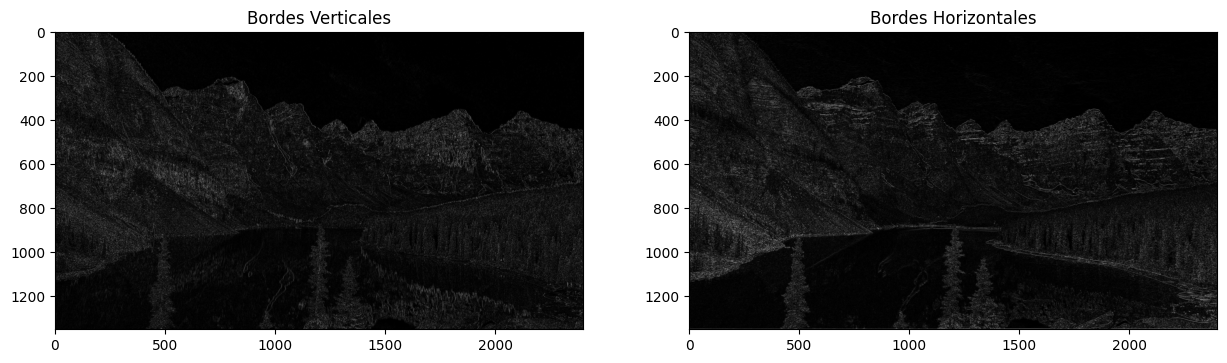

In [7]:
# 1. Define la variable 'sobel_x' (Bordes Verticales)
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# 2. Define la variable 'sobel_y' (Bordes Horizontales)
sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

# 3. Aplica la convolución a 'imagen_gris' para obtener las variables 'bordes_x' y 'bordes_y'
bordes_x = aplicar_convolucion(imagen_gris, sobel_x)
bordes_y = aplicar_convolucion(imagen_gris, sobel_y)

# VISUALIZACIÓN (No tocar)
if 'bordes_x' in locals() and 'bordes_y' in locals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    ax1.imshow(np.absolute(bordes_x), cmap='gray'); ax1.set_title("Bordes Verticales")
    ax2.imshow(np.absolute(bordes_y), cmap='gray'); ax2.set_title("Bordes Horizontales")
    plt.show()

---

## RETO: El Filtro Sharpen (Enfoque)
Ahora tú solo. Tienes que enfocar la imagen. Esto requiere tres pasos y mucha atención a los tipos de datos.

**Requisitos:**
1. Define un kernel de $3 \times 3$. 
   * El centro debe ser positivo (para mantener el pixel original).
   * Los vecinos directos (arriba, abajo, izq, der) deben ser negativos (para restar el promedio de los vecinos). 
   * **Importante:** La suma de todos los números del kernel debe ser 1.
2. Aplica el filtro.
3. **OBLIGATORIO (Clamping):** Al restar vecinos, el resultado tendrá valores negativos (negro más negro que el negro) y valores mayores a 255. Debes arreglarlo usando la función de NumPy que corta los valores (`clip`).

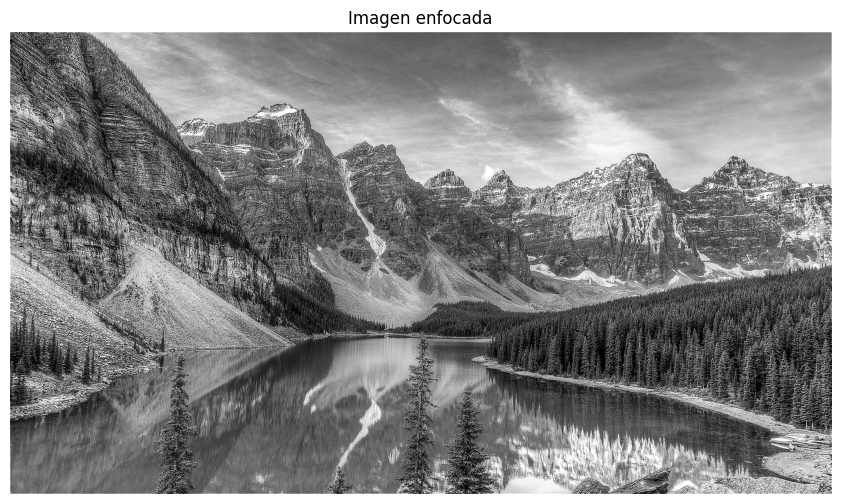

In [9]:
# 1. Definir Kernel
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1 ,0]
])

# 2. Aplicar Convolución
imagen_enfocada = aplicar_convolucion(imagen_gris, kernel_sharpen)
# 3. Corregir Rango (Clip) y Visualizar
imagen_clip = np.clip(imagen_enfocada, 0, 255)
plt.imshow(imagen_clip, cmap='gray')
plt.title("Imagen enfocada")
plt.axis('off')
plt.show()

---

# Siguiente nivel: Retos de Investigación
Si has llegado hasta aquí, ya sabes aplicar filtros. Ahora toca **experimentar**.
Los siguientes retos requieren que modifiques los tamaños y valores de los kernels para ver qué ocurre.

### Reto 1: El Tamaño Importa (Blur Masivo)
Hasta ahora hemos usado kernels de $3 \times 3$ o $5 \times 5$.
¿Qué pasa si intentamos hacer un suavizado con una vecindad GIGANTE?

**Misión:**
1. Crea un kernel de media de **$21 \times 21$** (o más).
2. Aplícalo a la imagen.
3. Observa: ¿Se sigue reconociendo la imagen? ¿Qué pasa con el tiempo de ejecución?

In [ ]:
# 1. Define el tamaño (Impar)
k_size = 21

# 2. Crea el kernel GIGANTE.
# Piensa bien: ¿Por cuánto tienes que dividir ahora para normalizar?
kernel_gigante = 

# 3. Mide el tiempo y aplica
inicio = time.time()
imagen_borrosa_total = 
fin = time.time()

print(f"Tiempo de procesamiento: {fin - inicio:.2f} segundos")

if 'imagen_borrosa_total' in locals():
    plt.imshow(imagen_borrosa_total, cmap='gray')
    plt.title(f"Blur Extremo ({k_size}x{k_size})")
    plt.show()

### Reto 2: Filtros Artísticos (Emboss / Relieve)
El filtro de Relieve (Emboss) da la sensación de que la imagen es de piedra tallada con una luz lateral.
Se basa en un kernel asimétrico parecido a este:

$$ Kernel = \begin{bmatrix} -2 & -1 & 0 \\ -1 & 1 & 1 \\ 0 & 1 & 2 \end{bmatrix} $$

**Misión:**
1. Define este kernel en NumPy.
2. Aplícalo.
3. **El problema:** Al sumar los valores del kernel el resultado es 0. Las zonas planas se volverán negras.
4. **La solución:** Queremos que el "cero" sea gris medio. **Suma 128** al resultado de la convolución antes de hacer el `clip` para desplazar el histograma.

In [ ]:
# 1. Define el Kernel Emboss


# 2. Aplica la convolución


# 3. Ajuste de luz (Offset) + Clip


# 4. Visualiza


---

# Ejercicios Avanzados
Estos ejercicios requieren mezclar todo lo aprendido y aplicar lógica matemática avanzada. No hay pistas fáciles.

### Reto 3: La Detección Perfecta (Magnitud del Gradiente)
Has calculado `bordes_x` (líneas verticales) y `bordes_y` (líneas horizontales) por separado en el ejercicio 3.
Pero un objeto tiene bordes en todas direcciones. ¿Cómo los unimos?

Usando el **Teorema de Pitágoras**.
Si X es un cateto e Y es otro cateto, la magnitud total del borde es la hipotenusa:

$$ Magnitud = \sqrt{X^2 + Y^2} $$

**Misión:** Calcula la magnitud combinada de los bordes. Crea una imagen que parezca un dibujo a lápiz perfecto.

In [ ]:
# 1. Recupera tus matrices 'bordes_x' y 'bordes_y' del ejercicio 3 (asegúrate de que existen)
# Nota: Usa las matrices originales con sus valores negativos, NO las de valor absoluto (abs_x).

# 2. Aplica la fórmula de Pitágoras
# Investiga qué función de numpy hace la raíz cuadrada y cómo elevar al cuadrado.


# 3. Normaliza
# La hipotenusa puede ser mayor que 255. Divide por el máximo valor de la matriz y multiplica por 255.


# 4. Visualiza


### Reto 4: "Unsharp Masking" (El algoritmo de Photoshop)
El filtro "Sharpen" que hicimos antes (kernel 3x3) es un poco tosco.
Los programas profesionales usan una técnica más elegante llamada **Unsharp Masking**.

**La Lógica:**
1.  Tengo la `Original`.
2.  Creo una versión borrosa: `Blurred` (usa un kernel de 5x5).
3.  Resto: `Mascara = Original - Blurred`. (Esto me deja solo los detalles finos).
4.  Sumo esos detalles a la original para exagerarlos: `Final = Original + (Mascara * cantidad)`.

**Misión:** Implementa este algoritmo paso a paso usando sumas y restas de matrices.

In [ ]:
# Tu código aquí. 
# Define pasos, variables intermedias y visualiza el resultado final.
